# 2.1. Área bajo restauración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Datos CBD

In [2]:
data = pd.read_excel("data/scbd-ort-GBF-INDICATOR-2.2-data.xlsx", header=0, sheet_name="BD_restoration_ecology")
data

,ID,Restoration approach,Restoration program,Restoration action,Institution,Year,Region,ha,Footnote,Source_link
0,RE-1,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Maule,2319.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
1,RE-2,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Ñuble,1247.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
2,RE-3,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Biobío,2608.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
3,RE-4,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,La Araucanía,2081.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
4,RE-5,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Los Ríos,3574.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
...,...,...,...,...,...,...,...,...,...,...
141,RE-142,Restoration ecology,GEF restauración de paisajes,Obras de conservación de suelos y cerco perime...,MMA / GEF,2023,Maule,15.00,GEF Indicator 4.1 – Landscapes under improved ...,GEF restauración de paisajes
142,RE-143,Restoration ecology,GEF restauración de paisajes,Sistema de tratamiento de aguas grises – Escue...,MMA / GEF,2023,Maule,0.50,GEF Indicator 4.1 – Landscapes under improved ...,GEF restauración de paisajes
143,RE-144,Restoration ecology,GEF restauración de paisajes,Mejoras de senderos en Lonquén y Fundo Curahué...,MMA / GEF,2023,Ñuble,26.60,GEF Indicator 4.1 – Landscapes under improved ...,GEF restauración de paisajes
144,RE-145,Restoration ecology,GEF restauración de paisajes,Habilitación de 30 obras de conservación de ag...,MMA / GEF,2023,Múltiples regiones,150.16,GEF Indicator 4.1 – Landscapes under improved ...,GEF restauración de paisajes


In [3]:
data["Region"] = data["Region"].replace({
    "Valparaiso": "Valparaíso",
    "Los ríos": "Los Ríos",
    "Los lagos": "Los Lagos",
    "Araucanía": "La Araucanía",
    "Múltiples regiones": "Interregional"
})

In [4]:
data_region = data.groupby('Region')['ha'].sum().reset_index()
data_region

,Region,ha
0,Antofagasta,261.000
1,Arica y Parinacota,3068.000
2,Atacama,158.000
3,Aysén,19168.000
4,Biobío,4264.694
5,Coquimbo,3101.030
6,Interregional,63124.160
7,La Araucanía,5563.800
8,Los Lagos,5979.020
9,Los Ríos,8809.000


In [5]:
list(data_region["Region"])

['Antofagasta',
 'Arica y Parinacota',
 'Atacama',
 'Aysén',
 'Biobío',
 'Coquimbo',
 'Interregional',
 'La Araucanía',
 'Los Lagos',
 'Los Ríos',
 'Magallanes',
 'Maule',
 'Metropolitana',
 "O'Higgins",
 'Tarapacá',
 'Valparaíso',
 'Ñuble']

In [6]:
region_order = [
    'Arica y Parinacota',
    'Tarapacá',
    'Antofagasta',
    'Atacama',
    'Coquimbo',
    'Valparaíso',
    'Metropolitana',
    "O'Higgins",
    'Maule',
    'Ñuble',
    'Biobío',
    'La Araucanía',
    'Los Ríos',
    'Los Lagos',
    'Aysén',
    'Magallanes',
    'Interregional',
]

In [7]:
data_region["Region"] = pd.Categorical(data_region["Region"],
                                       categories=region_order,
                                       ordered=True)
data_region.sort_values("Region", inplace=True)
data_region

,Region,ha
1,Arica y Parinacota,3068.000
14,Tarapacá,306.000
0,Antofagasta,261.000
2,Atacama,158.000
5,Coquimbo,3101.030
15,Valparaíso,2490.400
12,Metropolitana,692.226
13,O'Higgins,8164.140
11,Maule,6311.090
16,Ñuble,6032.700


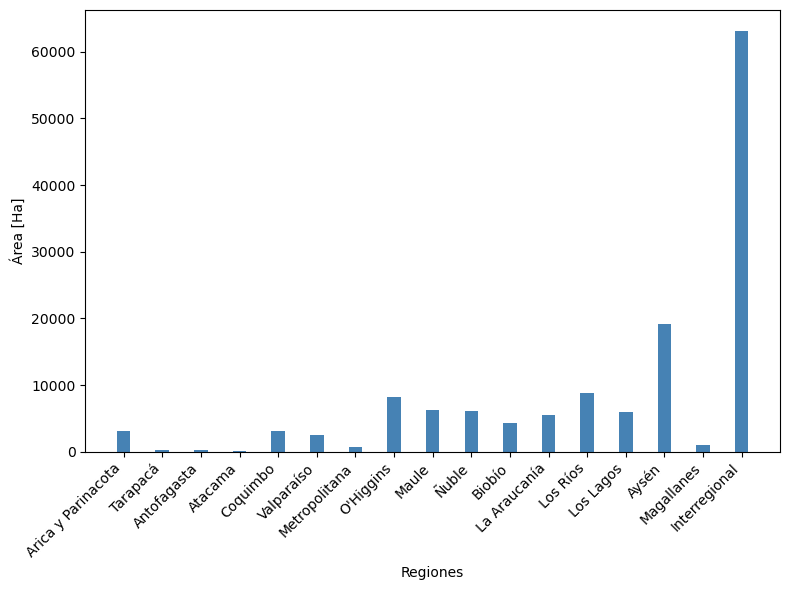

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

position = np.arange(len(data_region))
width = 0.35

ax.bar(position, data_region["ha"], width, label="Área [Ha]", color="steelblue")
ax.set_xlabel("Regiones")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(position)
ax.set_xticklabels(data_region["Region"], rotation=45, ha='right')

fig.savefig("regiones_cbd.png")

plt.tight_layout()

In [9]:
data_time = data.groupby('Year')['ha'].sum().reset_index()
data_time['ha (cumulative)'] = data_time['ha'].cumsum()
data_time = data_time.drop(4)
data_time["Year"] = data_time["Year"].astype(int)
data_time

,Year,ha,ha (cumulative)
0,2022,14537.90,14537.90
1,2023,16518.45,31056.35
2,2024,10640.00,41696.35
3,2025,25622.98,67319.33


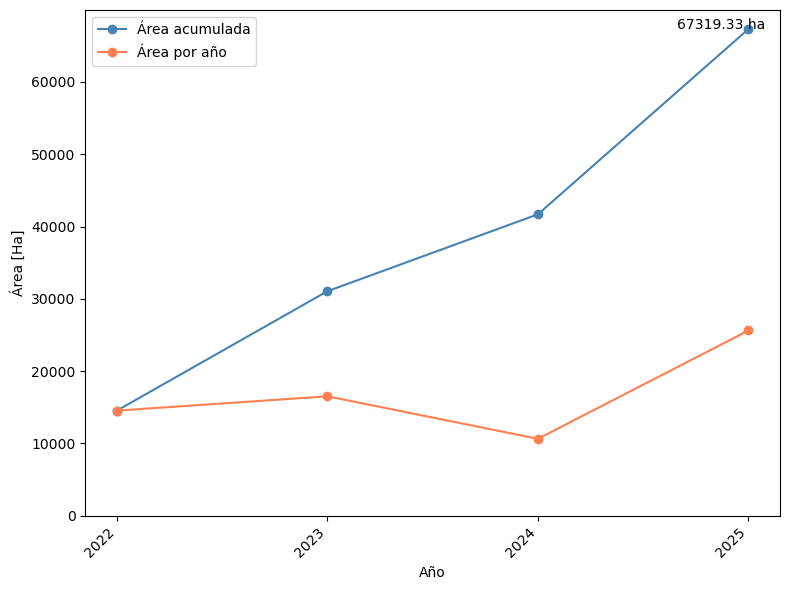

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_time["Year"], data_time["ha (cumulative)"], marker='o', color="steelblue", label="Área acumulada")
ax.text(2025 - 0.34, data_time["ha (cumulative)"][3], f'{data_time["ha (cumulative)"][3]} ha')
ax.set_xlabel("Año")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(data_time["Year"])
ax.set_xticklabels(data_time["Year"], rotation=45, ha='right')
ax.set_ylim(0)

# ax2 = ax.twinx()
ax.plot(data_time["Year"], data_time["ha"], marker='o', color="coral", label="Área por año")
ax.legend()

fig.savefig("years_cbd.png")

plt.tight_layout()

## Datos Nacionales

In [11]:
data = pd.read_excel("data/scbd-ort-GBF-INDICATOR-2.2-data.xlsx", header=0, sheet_name="BD_Landscape restoration")
data = data.drop(15)
data

,ID,Restoration program,Name,Year,Region,Source,ha
0,L-1,GEF Restauración de paisajes,Reserva de la Biosfera Fray Jorge,2023.0,Coquimbo,PRODOC GEF RESTAURACION,134311
1,L-2,GEF Restauración de paisajes,Corredor Bosques de Casablanca – Peñuelas – Qu...,2023.0,Valparaíso,PRODOC GEF RESTAURACION,75916
2,L-3,GEF Restauración de paisajes,Secano Costero – Nilahue (Región de O’Higgins),2023.0,O´Higgins,PRODOC GEF RESTAURACION,122947
3,L-4,GEF Restauración de paisajes,Curepto – Putú – Huenchullamí – Río Maule (Reg...,2023.0,Maule,PRODOC GEF RESTAURACION,150543
4,L-5,GEF Restauración de paisajes,Secano Interior – Altos de Ninhue (Región de Ñ...,2023.0,Ñuble,PRODOC GEF RESTAURACION,30633
5,L-6,GEF Restauración de paisajes,Cayumanque,2023.0,Ñuble,PRODOC GEF RESTAURACION,126168
6,L-7,GEF Restauración de paisajes,Nahuelbuta – Lanalhue,2023.0,Biobío,PRODOC GEF RESTAURACION,73232
7,L-8,Planes regionales de adaptación al cambio clim...,Medida A1.2.1 Region del Biobio: Reforzamiento...,2025.0,Biobío,NaN,1000
8,L-9,Planes regionales de adaptación al cambio clim...,Medida A1.2.1 Region del Biobio: Absorber CO2 ...,2025.0,Biobío,NaN,1000
9,L-10,Otros instrumentos de planificación a escala d...,Plan de Ordenamiento y Gestión Territorial par...,2000.0,Biobío,https://prela.mma.gob.cl/wp-content/uploads/Re...,36956


In [12]:
data["Region"] = data["Region"].replace({
    "O´Higgins": "O'Higgins",
})

In [13]:
data_region = data.groupby('Region')['ha'].sum().reset_index()
data_region

,Region,ha
0,Biobío,250388
1,Coquimbo,134311
2,Los Lagos,217936
3,Maule,150543
4,Metropolitana,84353
5,O'Higgins,122947
6,Valparaíso,75916
7,Ñuble,156801


In [14]:
region_order = [
    'Coquimbo',
    'Valparaíso',
    'Metropolitana',
    "O'Higgins",
    'Maule',
    'Ñuble',
    'Biobío',
    'Los Lagos',
]

In [15]:
data_region["Region"] = pd.Categorical(data_region["Region"],
                                       categories=region_order,
                                       ordered=True)
data_region.sort_values("Region", inplace=True)
data_region

,Region,ha
1,Coquimbo,134311
6,Valparaíso,75916
4,Metropolitana,84353
5,O'Higgins,122947
3,Maule,150543
7,Ñuble,156801
0,Biobío,250388
2,Los Lagos,217936


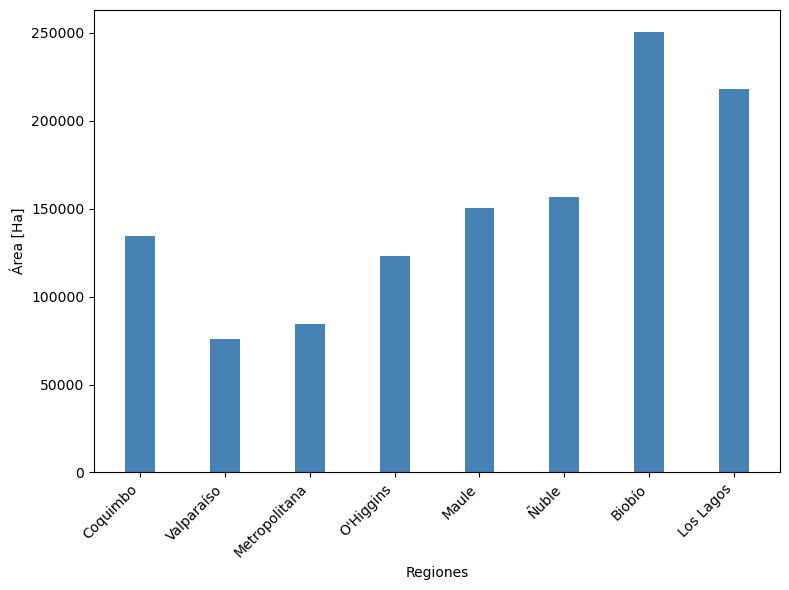

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

position = np.arange(len(data_region))
width = 0.35

ax.bar(position, data_region["ha"], width, label="Área [Ha]", color="steelblue")
ax.set_xlabel("Regiones")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(position)
ax.set_xticklabels(data_region["Region"], rotation=45, ha='right')

fig.savefig("regiones_nacional.png")

plt.tight_layout()

In [17]:
data_time = data.groupby('Year')['ha'].sum().reset_index()
data_time['ha (cumulative)'] = data_time['ha'].cumsum()
data_time["Year"] = data_time["Year"].astype(int)
data_time

,Year,ha,ha (cumulative)
0,2000,36956,36956
1,2008,57936,94892
2,2014,84353,179245
3,2017,160000,339245
4,2021,26000,365245
5,2023,713750,1078995
6,2024,112200,1191195
7,2025,2000,1193195


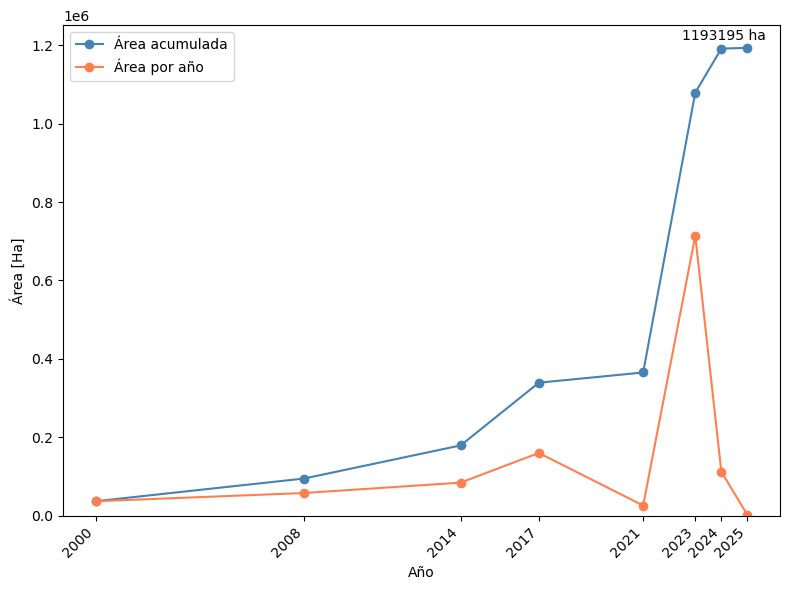

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_time["Year"], data_time["ha (cumulative)"], marker='o', color="steelblue", label="Área acumulada")
ax.text(2025 - 2.5, data_time["ha (cumulative)"][7] + 2e4, f'{data_time["ha (cumulative)"][7]} ha')
ax.set_xlabel("Año")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(data_time["Year"])
ax.set_xticklabels(data_time["Year"], rotation=45, ha='right')
ax.set_ylim(0)

# ax2 = ax.twinx()
ax.plot(data_time["Year"], data_time["ha"], marker='o', color="coral", label="Área por año")
ax.legend()

fig.savefig("years_nacional.png")

plt.tight_layout()